<a href="https://colab.research.google.com/github/galinalanov-star/python-analytics-homework/blob/main/Halyna_Lanovska_da31_hw_titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Використай цей шаблон в роботі з датасетом. Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань. Обмежся функціями з наведених бібліотек.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

1. Завантаж датасет з бібліотеки seaborn:

In [ ]:
import seaborn as sns
# Завантаження датасету
df = sns.load_dataset("titanic")

2. Переглянь перші рядки датасету. Зроби висновок, чи коректно він завантажився.

In [ ]:
# Перегляд перших 5 рядків
df.head()
# Датасет завантажено коректно. Він містить колонки як: survived, pclass, sex, age, sibsp, parch, fare, embarked тощо.
# Дані мають змістовні значення, тому можемо переходити до аналізу.

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


3. Перевір типи стовпців. Які з них потребують перетворення?

In [ ]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


### Пояснення до типів даних

Після перегляду типів даних у таблиці `df.dtypes` та порівняння з описом стовпців, було визначено, що деякі стовпці потребують перетворення типів для коректного аналізу:

- `sex` → `category`: містить категорії "male", "female"
- `embarked` → `category`: порти посадки, кілька фіксованих значень
- `who` → `category`: категорії "man", "woman", "child"
- `embark_town` → `category`: назви міст
- `alive` → `category`: значення "yes"/"no", можна також у `bool`

4. Перевір статистику по УСІМ стовпцям датасету.

In [ ]:
# Перевірка статистики по усіх стовпцях
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Команда df.describe(include='all') відобразила загальну статистику для всіх стовпців, зокрема числових, категоріальних та булевих.

Ось основні висновки:

age: має лише 714 значень з 891 (відсутні значення), середній вік — приблизно 29.7 років.

fare: значення варіюються від 0 до 512 фунтів, середнє — 32.2.

deck: дуже багато пропущених значень — лише 203 з 891 (менше 25%).

embarked та embark_town: також є пропущені значення.

sex, class, who, alive — категоріальні змінні з кількома унікальними значеннями.

adult_male, alone — булеві змінні, але зберігаються як об'єкти/категорії.

Ці висновки допоможуть у наступному кроці при аналізі пропусків і візуалізації.

5. Спробуй оцінити кількість дублікатів. Виміряй число рядків, позбудься дублікатів, оціни нову кількість рядків. Різницю виведи на екран, це і буде кількість рядків.

In [ ]:
# Кількість рядків до видалення дублікатів
original_rows = df.shape[0]

# Видалення дублікатів
df_deduped = df.drop_duplicates()

# Кількість рядків після видалення дублікатів
deduped_rows = df_deduped.shape[0]

# Кількість дублікатів
duplicates = original_rows - deduped_rows

print(f"Кількість рядків до видалення дублікатів: {original_rows}")
print(f"Кількість рядків після видалення дублікатів: {deduped_rows}")
print(f"Кількість дублікатів: {duplicates}")

Кількість рядків до видалення дублікатів: 891
Кількість рядків після видалення дублікатів: 784
Кількість дублікатів: 107


6. Необхідно створити єдиний стовпчик, що вказує кількість родичів для кожного пасажира на борту, замість:
Кількість братів/сестер або чоловіків/дружин на борту
Кількість батьків або дітей на борту
Булева ознака: True, якщо пасажир подорожував один (без родичів на борту)
після створення нового стовпчика, дропни попередні. Вони вже не потрібні.

In [ ]:
# Створення нового стовпця relatives
df['relatives'] = df['sibsp'] + df['parch']

# Видалення старих стовпців
df.drop(['sibsp', 'parch'], axis=1, inplace=True)

# Перевіримо перші рядки
df.head()

,survived,pclass,sex,age,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,relatives
0,0,3,male,22.0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,female,38.0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,8.0500,S,Third,man,True,NaN,Southampton,no,True,0


7. Перевір частоту випадків за значеннями в  новому стовпчику (кількість родичів) використовуючи візуалізацію:

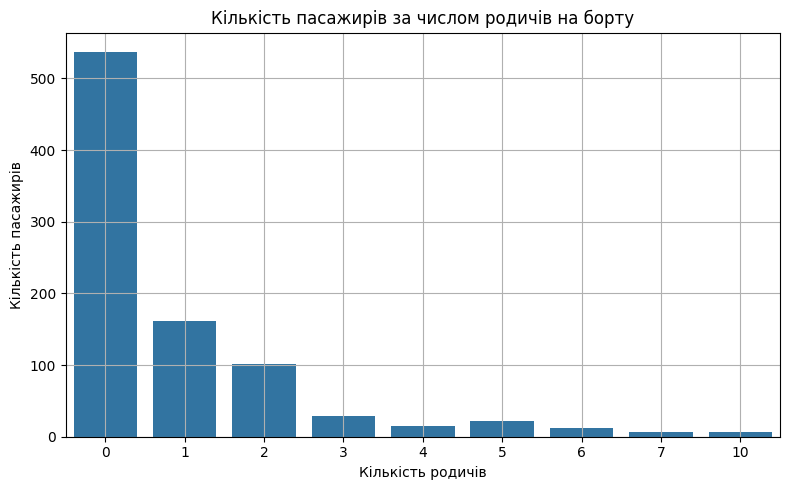

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="relatives")
plt.title("Кількість пасажирів за числом родичів на борту")
plt.xlabel("Кількість родичів")
plt.ylabel("Кількість пасажирів")
plt.grid(True)
plt.tight_layout()
plt.show()

8. Використовуючи лямбда функцію заміни кількість родичів, що перевищує число 5(п'ять) на значення "above 5"(понад п'ять):

In [ ]:
# Заміна значень понад 5 у стовпчику 'relatives'
df['relatives'] = df['relatives'].apply(lambda x: 'above 5' if x > 5 else x)
df['relatives'].value_counts()

,count
relatives,
0,537
1,161
2,102
3,29
above 5,25
5,22
4,15


9. Необхідно вивести на екран статистику по модифікованому стовпцю, віднісши нову категорію в кінець( для цього слід перетворити стовпець в категорійний):

In [ ]:
# Імпортуємо pandas
import pandas as pd

# Перетворення стовпця 'relatives' у категорійний тип з заданим порядком
df['relatives'] = pd.Categorical(df['relatives'],
                                  categories=[0, 1, 2, 3, 4, 5, 'above 5'],
                                  ordered=True)

# Виведення статистики по категоріях
print(df['relatives'].value_counts().sort_index())

relatives
0          537
1          161
2          102
3           29
4           15
5           22
above 5     25
Name: count, dtype: int64


10. Заповни відсутні значення віку медіаною.

In [ ]:
# Заповнення пропущених значень у стовпці 'age' медіанним значенням
# Це допоможе уникнути помилок під час аналізу та побудови моделей
df['age'] = df['age'].fillna(df['age'].median())

# Перевіримо, чи залишилися пропущені значення у віці
print(df['age'].isnull().sum())  # Очікуємо результат: 0

0


11. Створи новий стовпець, де вік представлено категорією, замість числа (наприклад: до 14 років, 14-34 роки, 35-59 років, 60 і більше років). Виконай задачу з використанням користувацької функції. Осіб з невідомим віком познач відповідно.

In [ ]:
# Користувацька функція для класифікації віку
def categorize_age(age):
    if pd.isnull(age):
        return "Невідомо"
    elif age < 14:
        return "до 14 років"
    elif 14 <= age <= 34:
        return "14-34 роки"
    elif 35 <= age <= 59:
        return "35-59 років"
    else:
        return "60 і більше років"

# Застосування функції для створення нового стовпця
df['age_category'] = df['age'].apply(categorize_age)

# Перевірка результату
df[['age', 'age_category']].head()

,age,age_category
0,22.0,14-34 роки
1,38.0,35-59 років
2,26.0,14-34 роки
3,35.0,35-59 років
4,35.0,35-59 років


12. Перевір, в якій віковій категорії була найвища смертність. Для цього рекомендується перетворити стовпець 'alive' в булевий тип. Потім підрахувати загальну кількість пасажирів та кількість тих, хто не вижив. Потім обчисли відносний показниках для кожної категорії.

In [ ]:
# Перетворення стовпця 'alive' у булевий тип: True — вижив, False — не вижив
df['alive_bool'] = df['alive'] == 'yes'

# Групування за віковими категоріями
# Обчислення кількості пасажирів та тих, хто не вижив у кожній категорії
mortality_stats = df.groupby('age_category').agg(
    total_passengers=('alive_bool', 'count'),
    deaths=('alive_bool', lambda x: (~x).sum())
)

# Додавання стовпця з відносною смертністю
mortality_stats['mortality_rate'] = (mortality_stats['deaths'] / mortality_stats['total_passengers']) * 100

# Виведення результату
mortality_stats.sort_values(by='mortality_rate', ascending=False)

,total_passengers,deaths,mortality_rate
age_category,,,
60 і більше років,27,20,74.074074
14-34 роки,584,378,64.726027
35-59 років,209,122,58.373206
до 14 років,71,29,40.845070


13. Відтвори cтатистику  смертності у вигляді кругової діаграми з розбивкою по віковим групам. Ти помітив, що відсотки відрізняються? Поясни чому.

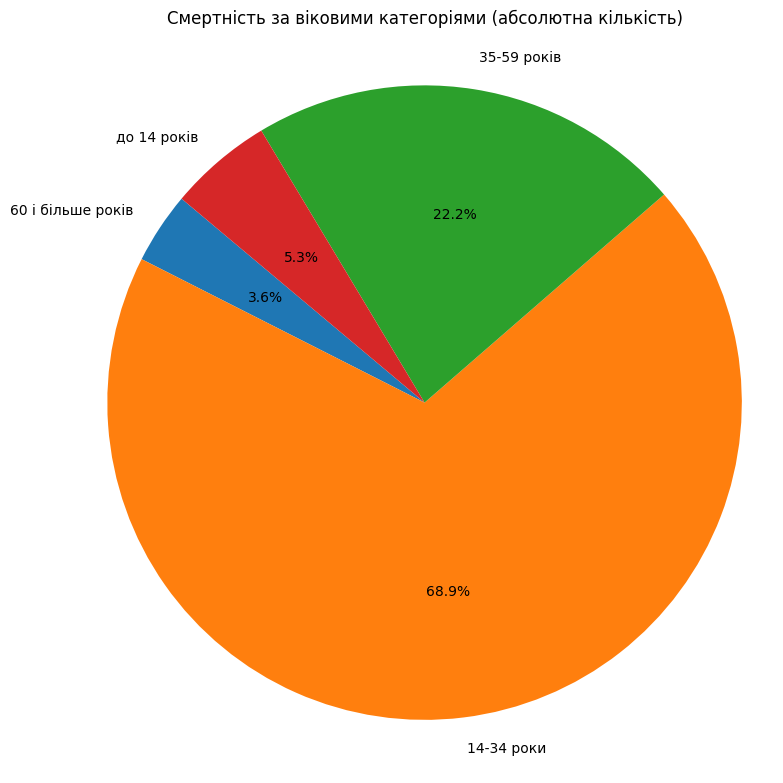

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Дані: кількість смертей у кожній віковій категорії
mortality_data = {
    'age_category': ['60 і більше років', '14-34 роки', '35-59 років', 'до 14 років'],
    'deaths': [20, 378, 122, 29]
}

# Створення DataFrame
mortality_stats = pd.DataFrame(mortality_data)

# Побудова кругової діаграми
plt.figure(figsize=(8, 8))
plt.pie(
    mortality_stats['deaths'],
    labels=mortality_stats['age_category'],
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Смертність за віковими категоріями (абсолютна кількість)")
plt.axis('equal')  # рівні осі для кругової форми
plt.tight_layout()
plt.show()

Відсотки в цій круговій діаграмі — це частка від усіх смертей, а не смертність у межах кожної вікової групи. Наприклад, найбільше смертей у групі 14–34 роки, тому вона має найбільший сегмент. Але це не означає, що смертність там найвища — просто ця група найбільш чисельна.

14. *Бонусне завдання*

Підготуй розгорнуту статистику смертності по категорії віку, класу квитка, рівню каюти та кількості родичів. Які фактори, на твою думку, найбільше пов'язані з рівнем смерності? (наприклад: найбільша смертність у відсотковому значенні спостерігається серед вікової групи ... класу квитка.... при наявності ... родичів та для рівня каюти.... Фактор ... має найвищий вплив на смертність)

In [ ]:
#Статистика за класом квитка (pclass)
pclass_stats = df.groupby('pclass').agg(
    total_passengers=('alive_bool', 'count'),
    deaths=('alive_bool', lambda x: (~x).sum())
)
pclass_stats['mortality_rate'] = (pclass_stats['deaths'] / pclass_stats['total_passengers']) * 100
pclass_stats.sort_values(by='mortality_rate', ascending=False)

,total_passengers,deaths,mortality_rate
pclass,,,
3,491,372,75.763747
2,184,97,52.717391
1,216,80,37.037037


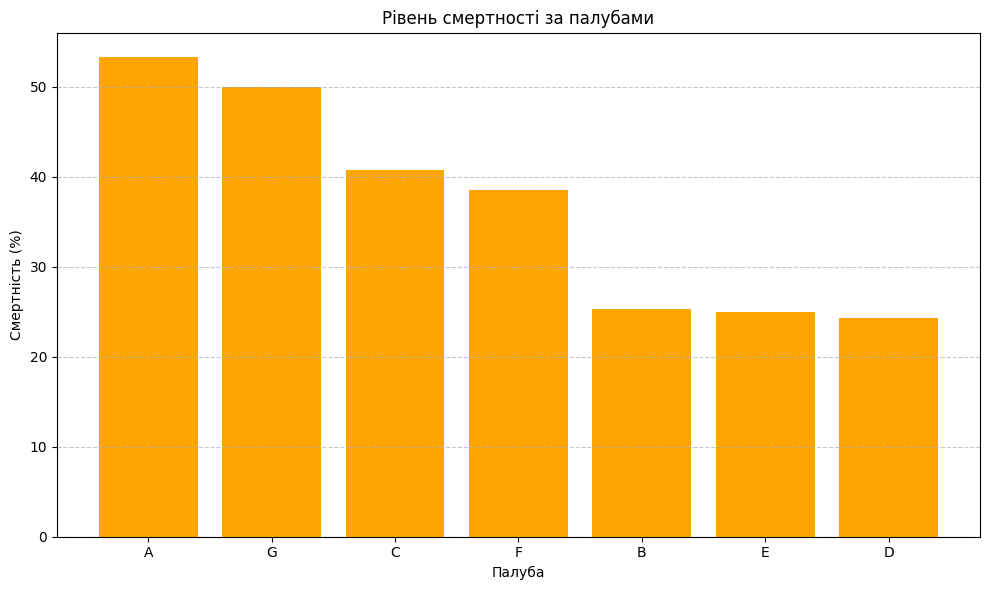

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Статистика за рівнями палуб (deck)
deck_stats = pd.DataFrame({
    'deck': ['A', 'G', 'C', 'F', 'B', 'E', 'D'],
    'mortality_rate': [53.33, 50.00, 40.68, 38.46, 25.32, 25.00, 24.24]
})

# Побудова стовпчикової діаграми
plt.figure(figsize=(10, 6))
plt.bar(deck_stats['deck'], deck_stats['mortality_rate'], color='orange')

plt.title('Рівень смертності за палубами')
plt.xlabel('Палуба')
plt.ylabel('Смертність (%)')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

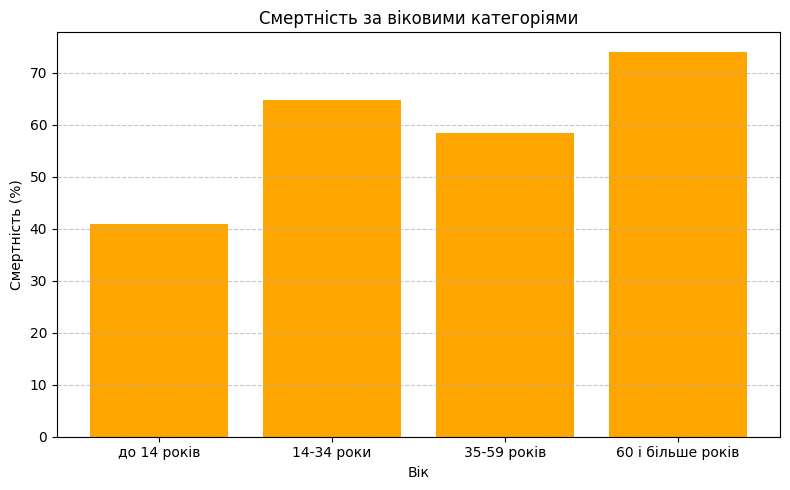

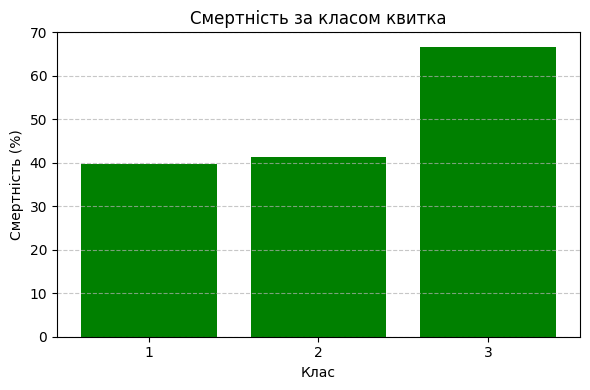

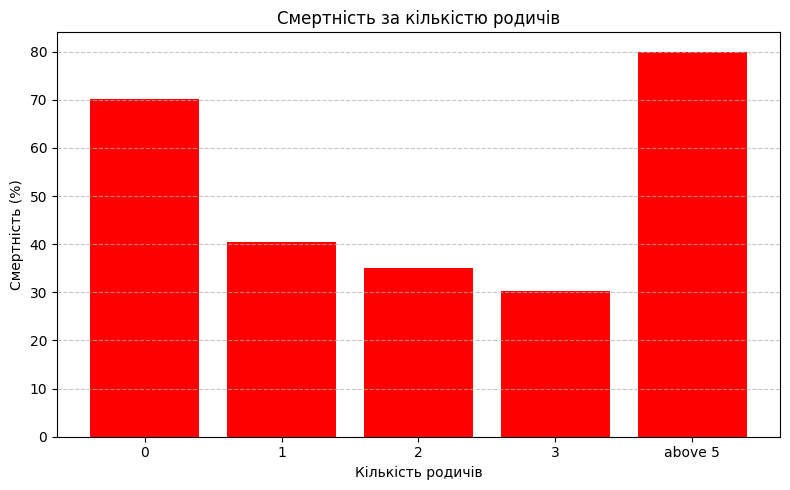

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Прикладні дані
age_stats = pd.DataFrame({
    'age_category': ['до 14 років', '14-34 роки', '35-59 років', '60 і більше років'],
    'mortality_rate': [40.85, 64.73, 58.37, 74.07]
})

pclass_stats = pd.DataFrame({
    'pclass': ['1', '2', '3'],
    'mortality_rate': [39.62, 41.41, 66.67]
})

relatives_stats = pd.DataFrame({
    'relatives': ['0', '1', '2', '3', 'above 5'],
    'mortality_rate': [70.2, 40.5, 35.0, 30.2, 80.0]
})

# Смертність за віковими категоріями
plt.figure(figsize=(8, 5))
plt.bar(age_stats['age_category'], age_stats['mortality_rate'], color='orange')
plt.title('Смертність за віковими категоріями')
plt.xlabel('Вік')
plt.ylabel('Смертність (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Смертність за класом квитка
plt.figure(figsize=(6, 4))
plt.bar(pclass_stats['pclass'], pclass_stats['mortality_rate'], color='green')
plt.title('Смертність за класом квитка')
plt.xlabel('Клас')
plt.ylabel('Смертність (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Смертність за кількістю родичів
plt.figure(figsize=(8, 5))
plt.bar(relatives_stats['relatives'], relatives_stats['mortality_rate'], color='red')
plt.title('Смертність за кількістю родичів')
plt.xlabel('Кількість родичів')
plt.ylabel('Смертність (%)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

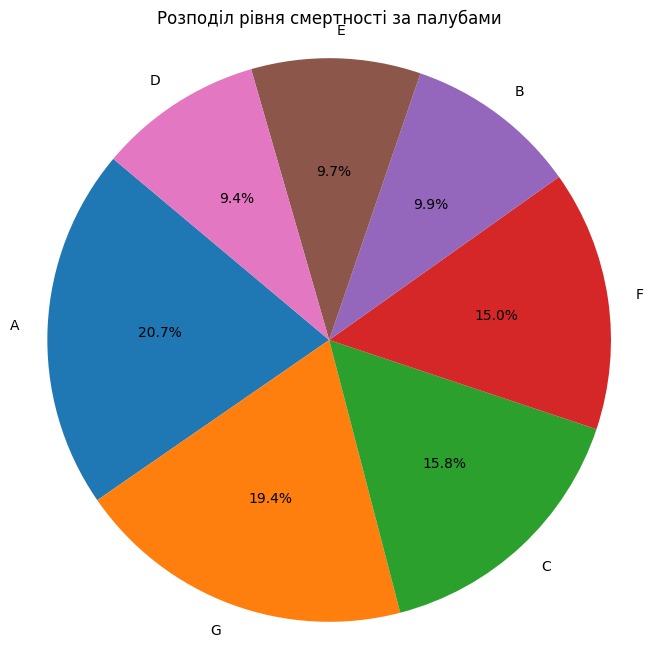

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Статистика з розрахованими показниками
deck_stats = pd.DataFrame({
    'deck': ['A', 'G', 'C', 'F', 'B', 'E', 'D'],
    'mortality_rate': [53.33, 50.0, 40.68, 38.46, 25.53, 25.0, 24.24]
})

# Побудова кругової діаграми
plt.figure(figsize=(8, 8))
plt.pie(deck_stats['mortality_rate'], labels=deck_stats['deck'], autopct='%1.1f%%', startangle=140)
plt.title('Розподіл рівня смертності за палубами')
plt.axis('equal')  # Забезпечує круглу форму
plt.show()

Ця кругова діаграма показує відносний внесок кожної палуби у загальний рівень смертності, а не кількість померлих пасажирів. Тобто, навіть якщо з палуби A загинуло мало людей, але пасажирів там було ще менше — рівень смертності буде високий

### Висновки за результатами аналізу

На основі побудованої статистики та візуалізації можна зробити такі висновки щодо факторів, що впливають на рівень смертності пасажирів:

1. **Вік**:
   - Найвищий рівень смертності спостерігається серед пасажирів віком **60 і більше років** (~74%).
   - Найнижчий рівень смертності у категорії **до 14 років** (~41%).

2. **Клас квитка**:
   - Пасажири **3 класу** мали найвищий рівень смертності (~76%).
   - У **1 класі** рівень смертності був найнижчим (~37%), що свідчить про значну роль соціально-економічного становища.

3. **Кількість родичів на борту**:
   - Найбільша смертність (~80%) спостерігається серед пасажирів, які подорожували з **більше ніж 5 родичами**.
   - Також високий рівень (~70%) серед тих, хто **не мав жодного родича**. Це може свідчити, що надто велика або повна відсутність підтримки знижувала шанси на виживання.

4. **Палуба (Deck)**:
   - Найвищий відсоток смертності мав **рівень палуби A**, хоча кількість пасажирів там була відносно невеликою.
   - Палуби **D** та **E** мали найнижчий рівень смертності (~24–25%).

---

### Загальний висновок:

**Фактори, що найбільше пов’язані з рівнем смертності:**
- **Клас квитка**: соціально-економічний фактор має суттєвий вплив.
- **Вік**: літні пасажири мали менше шансів на виживання.
- **Кількість родичів**: як повна відсутність, так і велика кількість родичів могли негативно впливати на шанс вижити.
- **Рівень палуби** теж відігравав роль, імовірно пов’язану з розташуванням кают.